<a href="https://colab.research.google.com/github/ziadm8692-glitch/Data-Analysis-Portfolio/blob/main/Amzion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df =pd.read_csv("/content/Amazon.csv")
df.head(5)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000927,12/29/2024,CUST008848,Vivaan Patel,P00011,Fitness Band,Home & Kitchen,FitLife,2,586.90,0.0,58.69,2.33,1234.82,Net Banking,Delivered,San Antonio,TX,United States,SELL01062
1,ORD0005281,12/29/2024,CUST017032,Vikas Sharma,P00011,Fitness Band,Sports & Outdoors,NexPro,5,561.88,0.0,505.69,14.28,3329.37,UPI,Delivered,Houston,TX,United States,SELL00572
2,ORD0010427,12/29/2024,CUST013630,Simran Mehta,P00050,Novel Bestseller,Books,Zenith,2,164.16,0.2,47.28,14.08,324.02,Credit Card,Delivered,Jacksonville,FL,Canada,SELL00594
3,ORD0010760,12/29/2024,CUST038154,Arjun Verma,P00047,Memory Card 128GB,Clothing,CoreTech,4,572.50,0.1,164.88,13.67,2239.55,Credit Card,Delivered,Austin,TX,United States,SELL01809
4,ORD0011236,12/29/2024,CUST016297,Mohit Kumar,P00002,Bluetooth Speaker,Electronics,UrbanStyle,4,476.87,0.0,152.60,2.05,2062.13,Credit Card,Shipped,Phoenix,AZ,United States,SELL00383


#  cleaning Data

In [ ]:
df.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


In [ ]:
df.dtypes

,0
OrderID,object
OrderDate,object
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [ ]:
df['OrderDate']=pd.to_datetime(df['OrderDate'])

In [ ]:
df.dtypes

,0
OrderID,object
OrderDate,datetime64[ns]
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [ ]:
df.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


In [ ]:
df.duplicated().sum(

)

np.int64(0)

In [ ]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

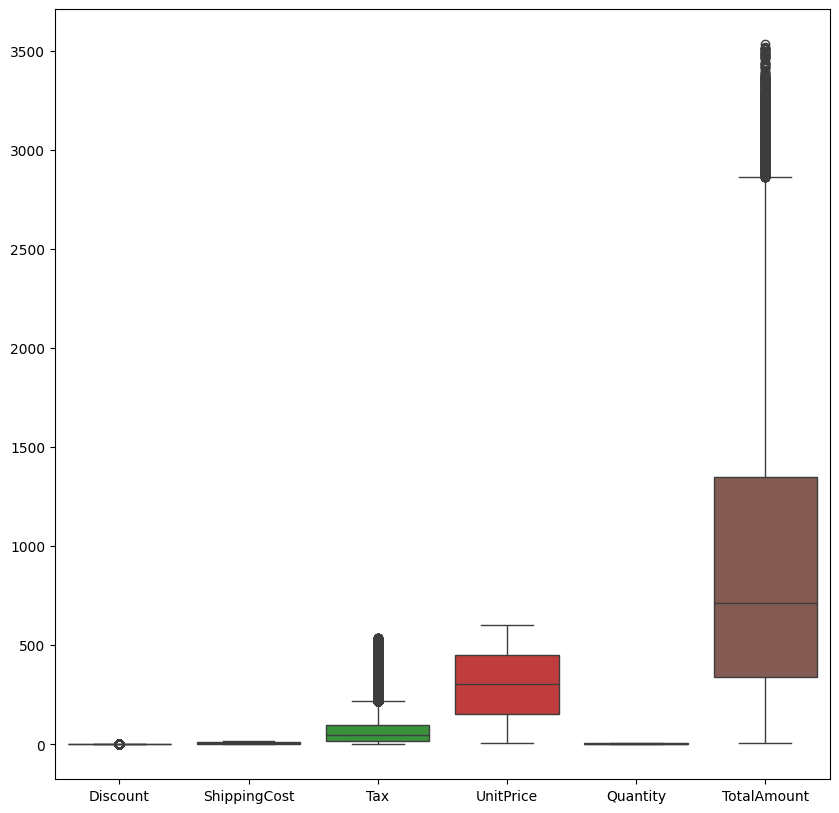

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(df[['Discount','ShippingCost','Tax','UnitPrice','Quantity','TotalAmount']])
plt.show()

In [ ]:
Q1=df[['TotalAmount','Tax','Discount','ShippingCost','Quantity']].quantile(0.25)
Q3=df[['TotalAmount','Tax','Discount','ShippingCost','Quantity']].quantile(0.75)
IQR=Q3-Q1
lowr=Q1-1.5*IQR
upper=Q3+1.5*IQR
df[['TotalAmount','Tax','Discount','ShippingCost','Quantity']]=df[['TotalAmount','Tax','Discount','ShippingCost','Quantity']].clip(lowr,upper,axis=1)

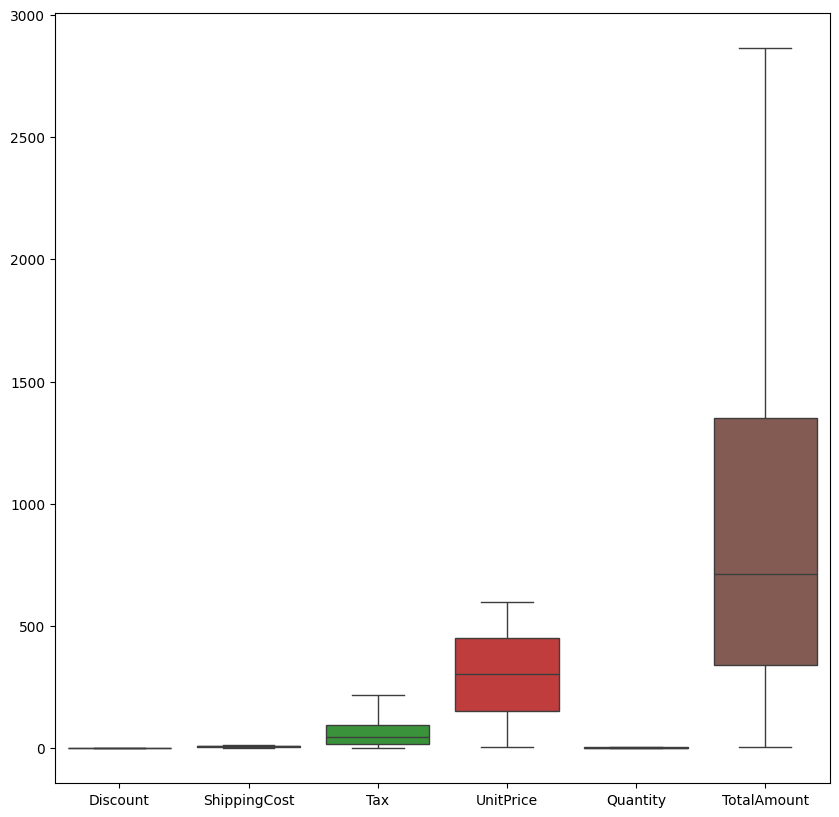

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(df[['Discount','ShippingCost','Tax','UnitPrice','Quantity','TotalAmount']])
plt.show()

# ***Sehr Wichtig***

In [ ]:
df["Gross Sales"]=df['Quantity']*df["UnitPrice"]

In [ ]:
df["Discount Amount"]=df['Gross Sales']*df['Discount']

In [ ]:
df['Net Sales']=df['Gross Sales']-df['Discount Amount']

In [ ]:
df['Final Amount'] = df['Net Sales'] + df['Tax']

In [ ]:
df['Tax Rate %'] = (df['Tax'] / df['Net Sales']) * 100

In [ ]:
df['Shipping %'] = (df['ShippingCost'] / df['TotalAmount']) * 100

--------------------------------------------------------------------------------

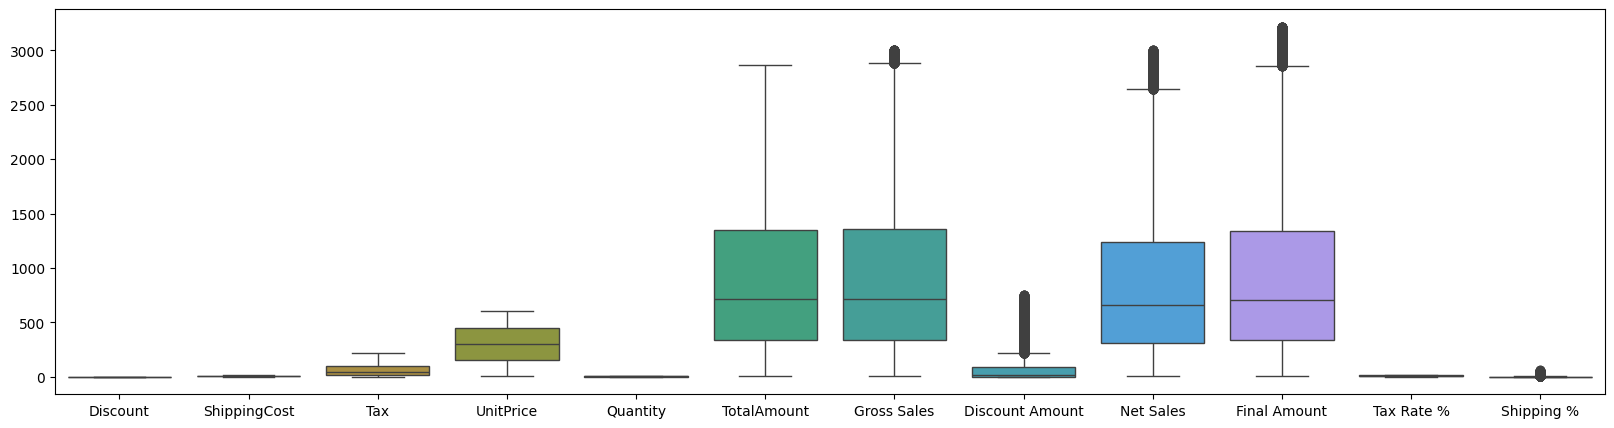

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(df[['Discount','ShippingCost','Tax','UnitPrice','Quantity','TotalAmount','Gross Sales','Discount Amount','Net Sales','Final Amount','Tax Rate %','Shipping %']])
plt.show()

In [ ]:
Q1=df[['Gross Sales','Discount Amount','Net Sales','Final Amount','Shipping %']].quantile(0.25)
Q3=df[['Gross Sales','Discount Amount','Net Sales','Final Amount','Shipping %']].quantile(0.75)
IQR=Q3-Q1
Lower=Q1-1.5*IQR
Upper=Q3+.15*IQR
df[['Gross Sales','Discount Amount','Net Sales','Final Amount','Shipping %']]=df[['Gross Sales','Discount Amount','Net Sales','Final Amount','Shipping %']].clip(Lower,Upper,axis=1)

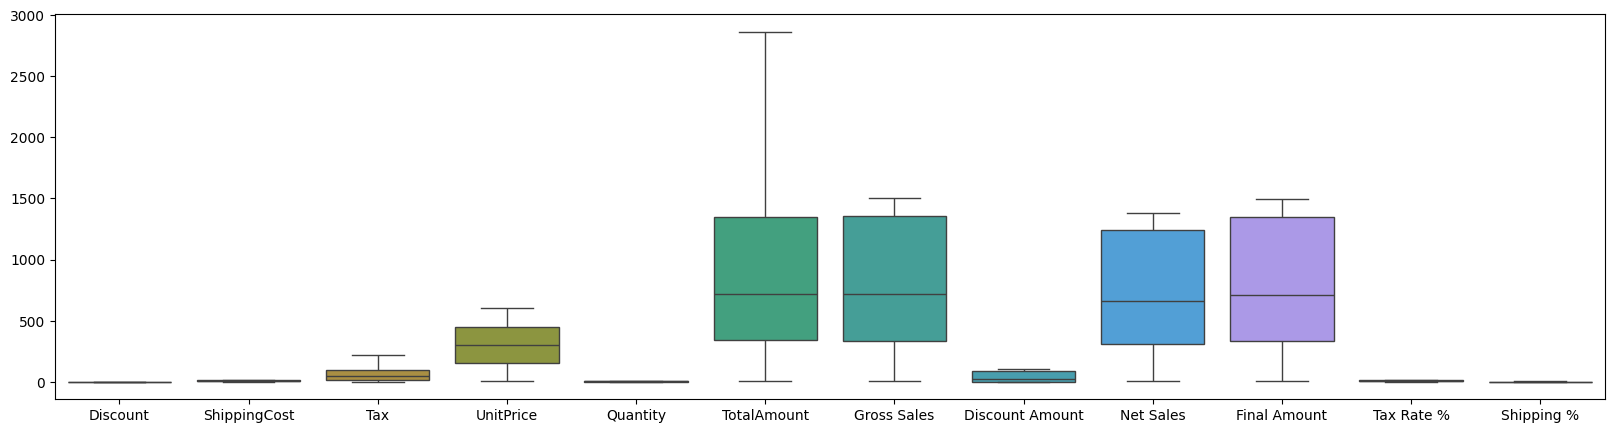

In [ ]:
plt.figure(figsize=(20,5))
sns.boxplot(df[['Discount','ShippingCost','Tax','UnitPrice','Quantity','TotalAmount','Gross Sales','Discount Amount','Net Sales','Final Amount','Tax Rate %','Shipping %']])
plt.show()

In [ ]:
df['year']=df['OrderDate'].dt.year

In [ ]:
df['Month']=df['OrderDate'].dt.month

In [ ]:
df.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


# ***EAD Data***

In [ ]:
top_10_products=df.groupby('ProductName')['Net Sales'].sum().nlargest(10).index
df_top=df[df['ProductName'].isin(top_10_products)]

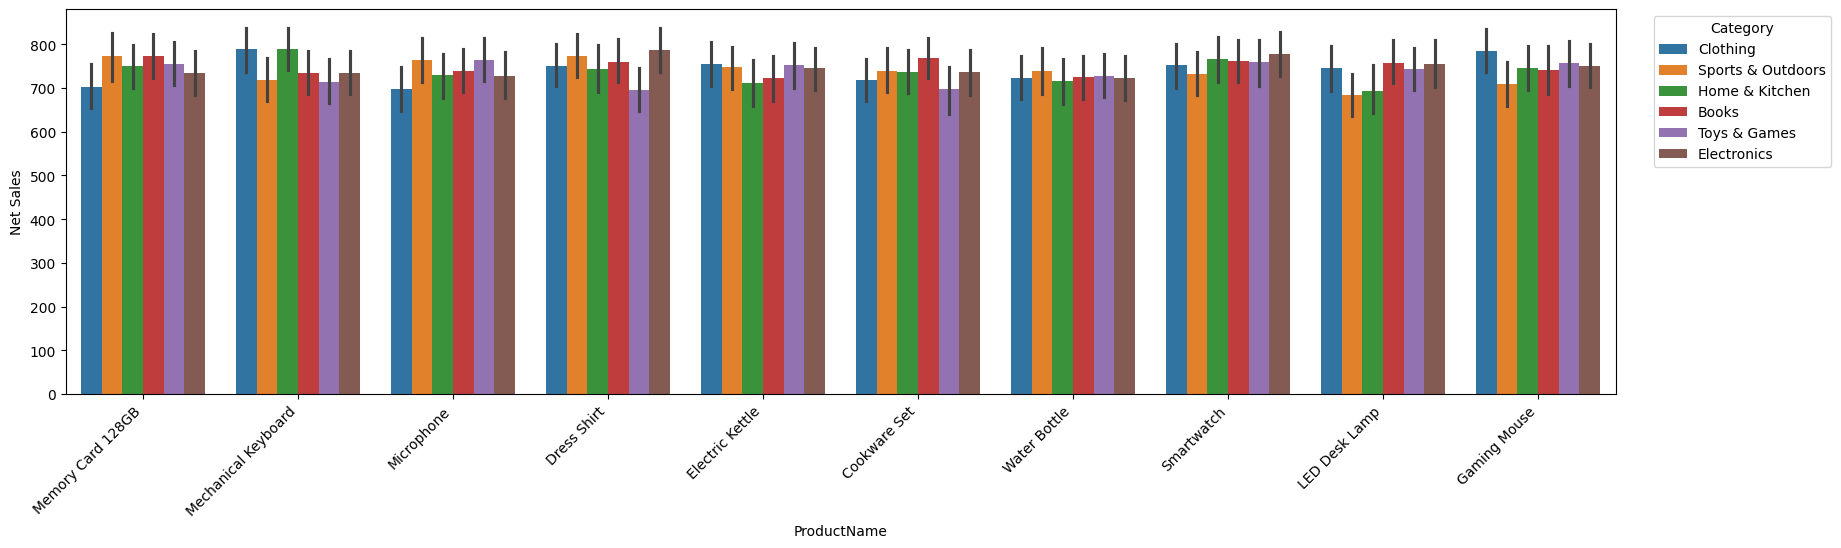

In [ ]:
plt.figure(figsize=(20,5))
sns.barplot(data=df_top, x="ProductName", y="Net Sales",hue="Category")
plt.xticks(rotation=45,ha='right')
ax=plt.gca()
sns.move_legend(ax,bbox_to_anchor=(1.02,1),loc='upper left',title='Category')
plt.show()

In [ ]:
top3_of_brand=df.groupby('Brand')['Final Amount'].sum().nlargest(3).index
df_top3=df[df['Brand'].isin(top3_of_brand)]

In [ ]:
df['year'] = df['year'].fillna(0).astype(int)

<Figure size 2000x500 with 0 Axes>

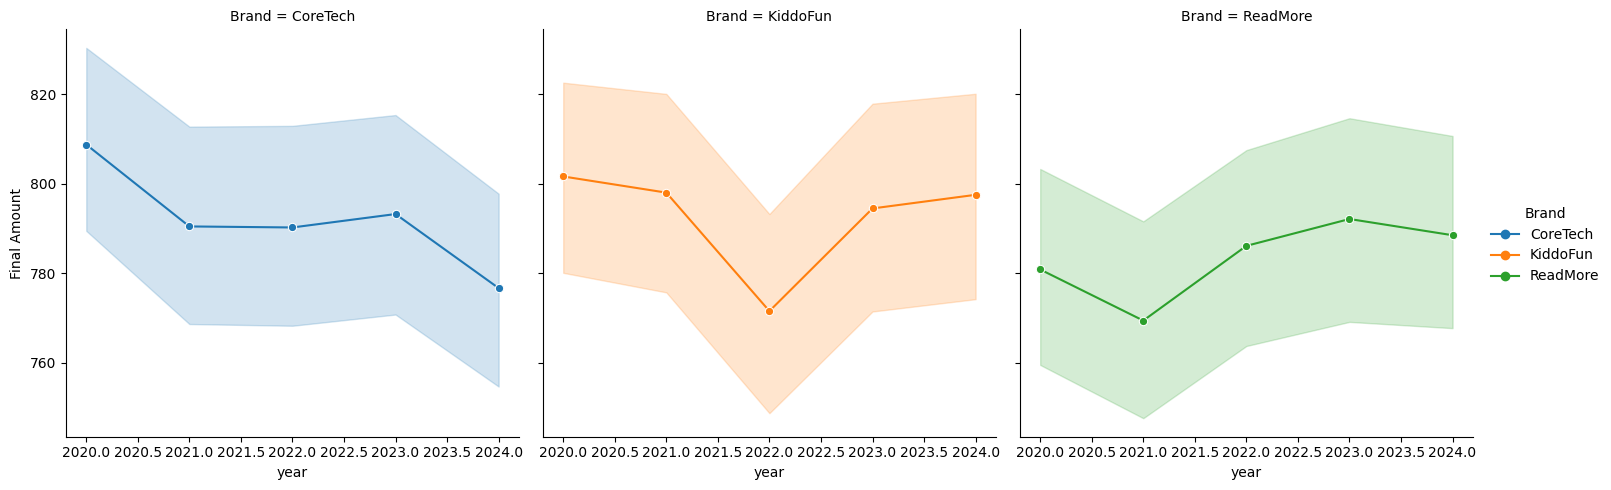

In [ ]:
plt.figure(figsize=(20,5))
sns.relplot(x='year', y='Final Amount', data=df_top3, kind='line',hue='Brand',col='Brand',marker='o')
plt.show()

In [ ]:
monthly_counts = df.groupby(['year', 'Month'])['CustomerID'].nunique().reset_index()
average_customers_per_month = monthly_counts['CustomerID'].mean()

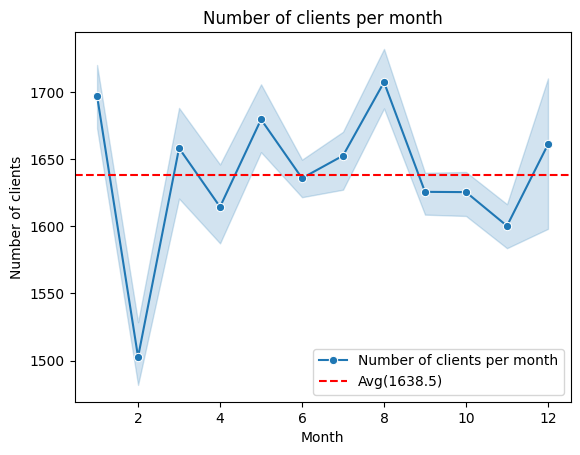

In [ ]:
sns.lineplot(data=monthly_counts, x='Month', y='CustomerID', marker='o', label='Number of clients per month')
plt.axhline(average_customers_per_month, color='red', linestyle='--', label=f'Avg({average_customers_per_month:.1f})')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Number of clients')
plt.title('Number of clients per month')
plt.show()

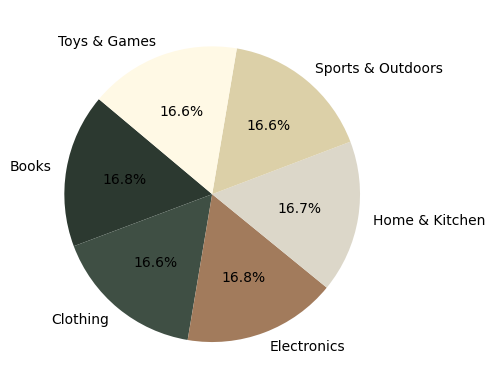

In [ ]:
c=df.groupby("Category")['Tax Rate %'].mean()
plt.pie(c.values,labels=c.index,autopct='%1.1f%%',colors=['#2C3930','#3F4F44','#A27B5C','#DCD7C9','#DCD0A8','#FFF9E5'],startangle=140)
plt.show()

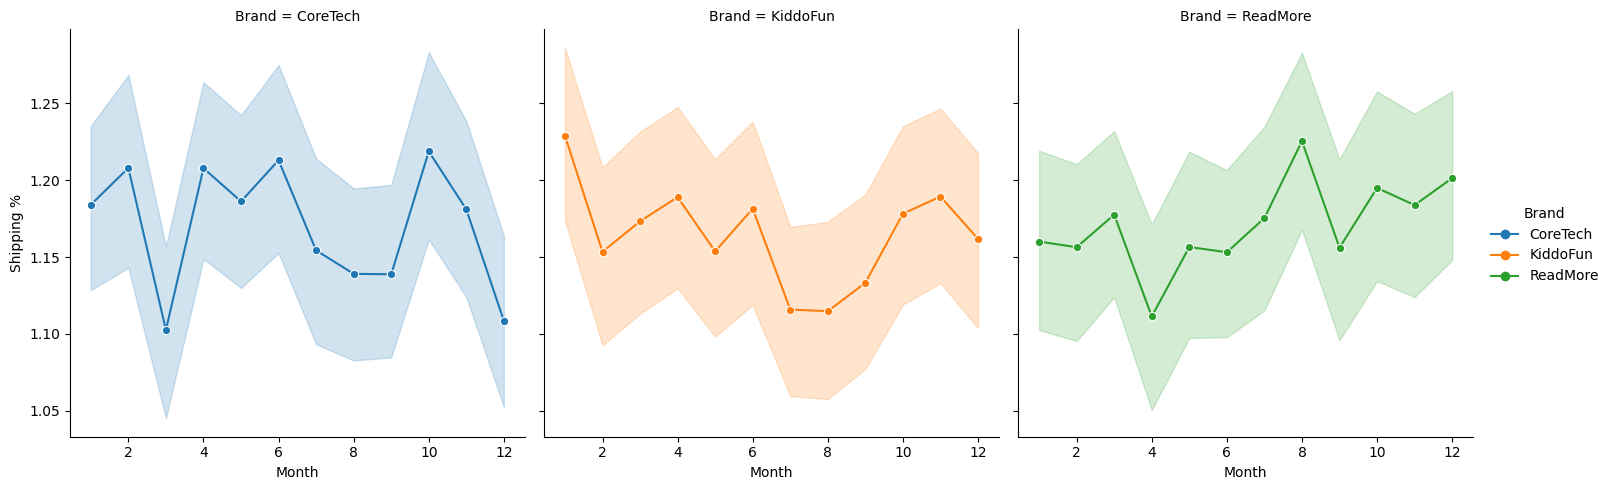

In [ ]:
sns.relplot(x='Month',y='Shipping %',data=df_top3,hue='Brand',col='Brand',marker='o',kind='line')
plt.show()

In [ ]:
v=df['Gross Sales'].sum()
print(v)

79534344.55312501


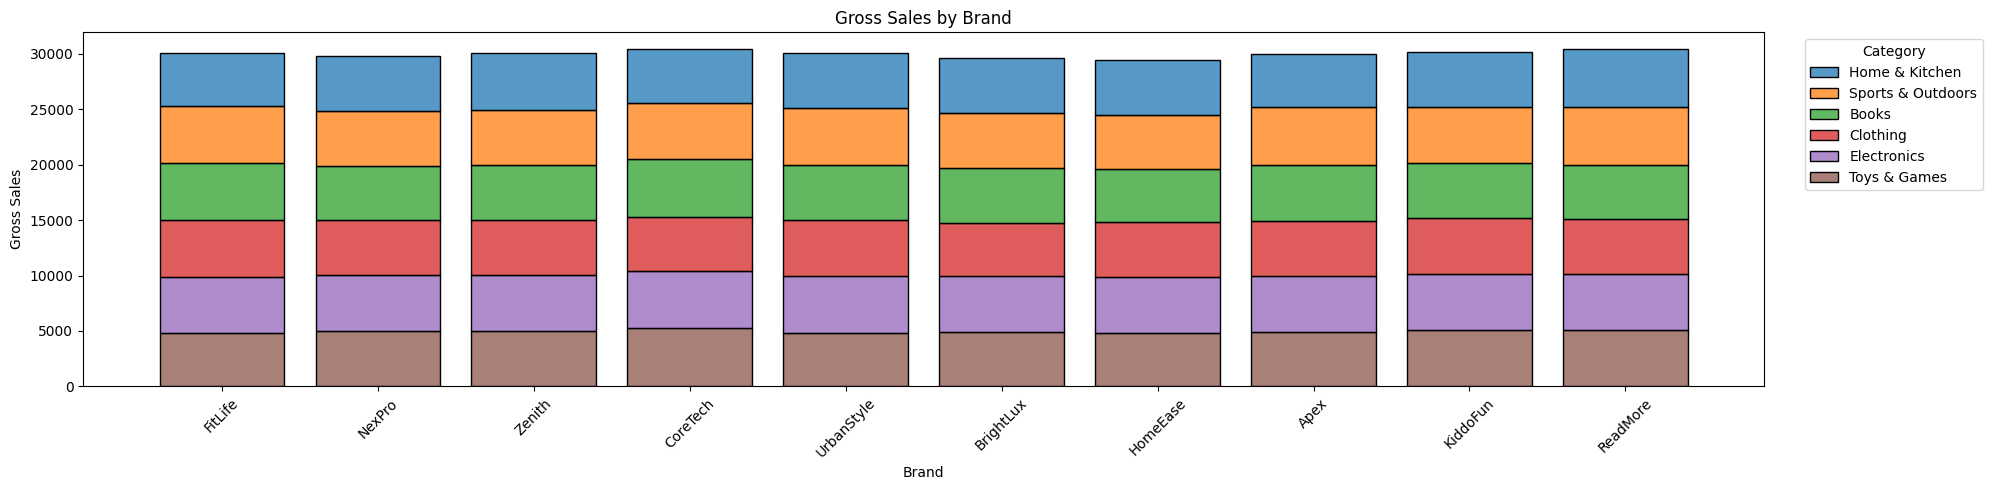

In [ ]:
plt.figure(figsize=(20,5))
sns.histplot(data=df, x='Brand' , hue ='Category',weights= 'Quantity',multiple='stack' , shrink=0.8)
plt.xlabel('Brand')
plt.ylabel('Gross Sales')
plt.title('Gross Sales by Brand')

ax = plt.gca()
sns.move_legend(ax, bbox_to_anchor=(1.02, 1), loc='upper left', title='Category')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
top_10_City=df.groupby('City')['Final Amount'].sum().nlargest(5).index
df_top10=df[df['City'].isin(top_10_City)]

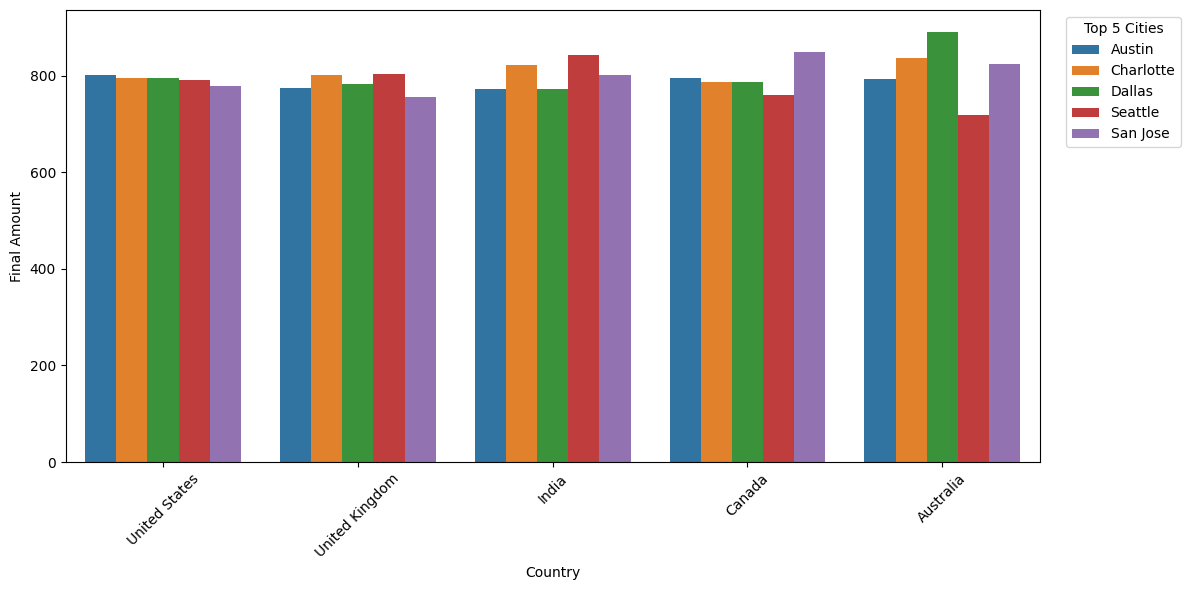

In [ ]:

top_5_City = df.groupby('City')['Final Amount'].sum().nlargest(5).index
df_top5= df[df['City'].isin(top_10_City)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top5, x='Country', y='Final Amount', hue='City', errorbar=None)
plt.xticks(rotation=45)
plt.legend(title='Top 5 Cities', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

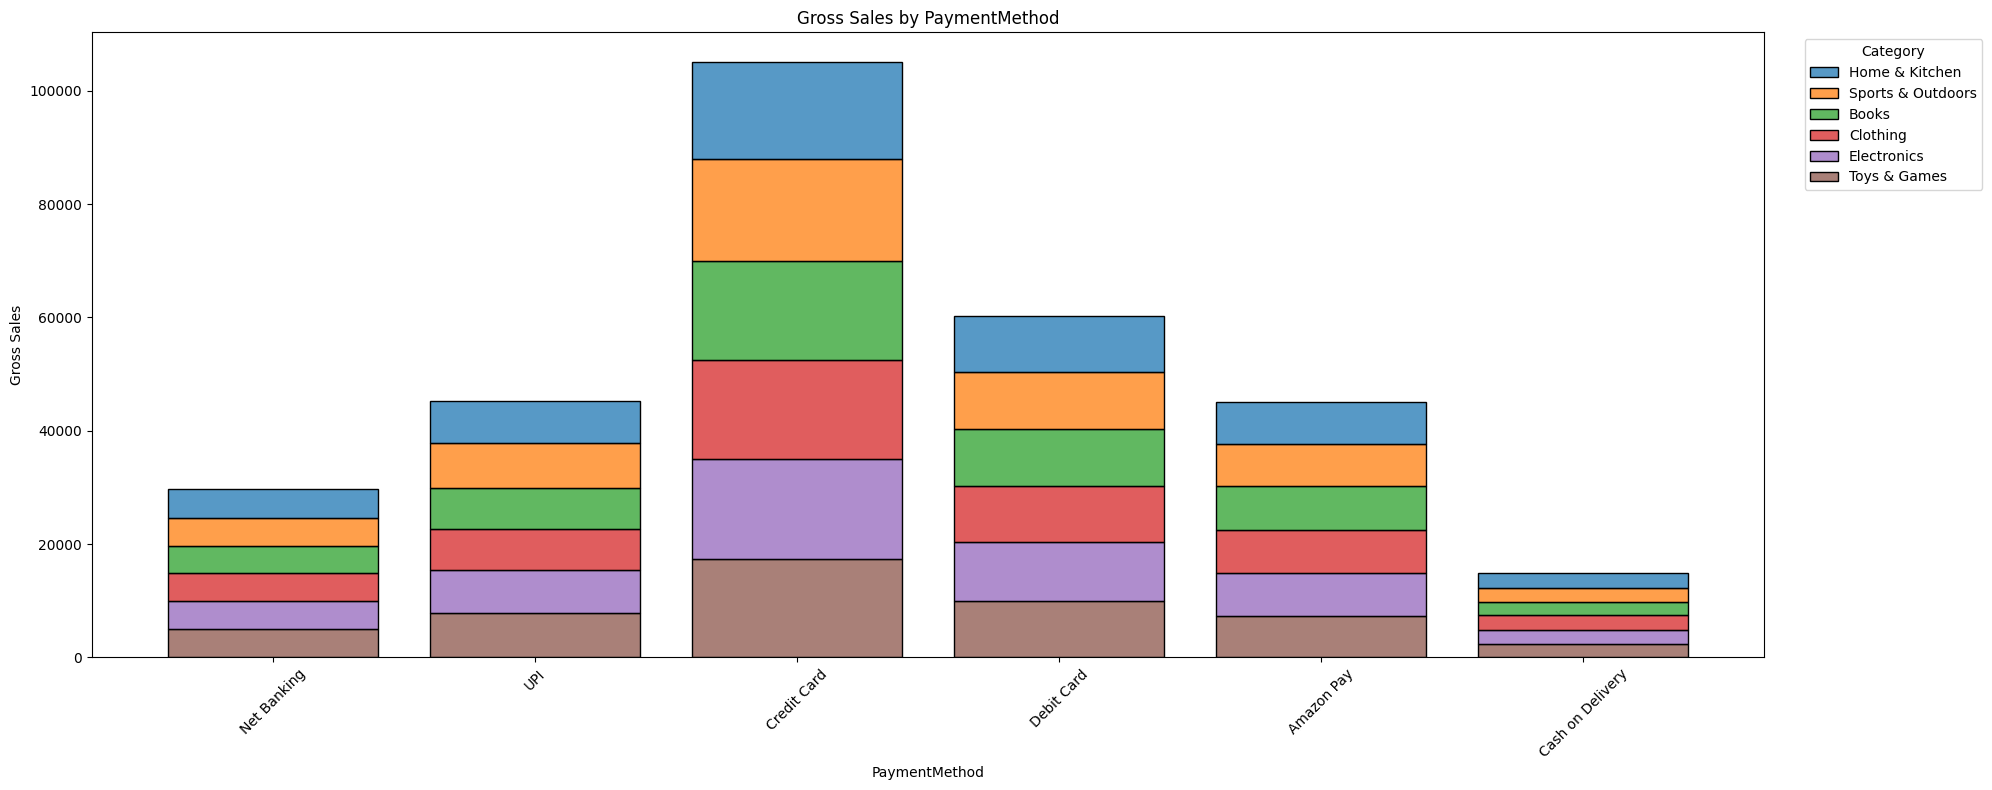

In [ ]:
plt.figure(figsize=(20,8))

sns.histplot(data=df, x='PaymentMethod', hue='Category', weights='Quantity', multiple='stack', shrink=0.8)

plt.xlabel('PaymentMethod')
plt.ylabel('Gross Sales')
plt.title('Gross Sales by PaymentMethod')
plt.xticks(rotation=45)


ax = plt.gca()
sns.move_legend(ax, bbox_to_anchor=(1.02, 1), loc='upper left', title='Category')

plt.tight_layout()
plt.show()

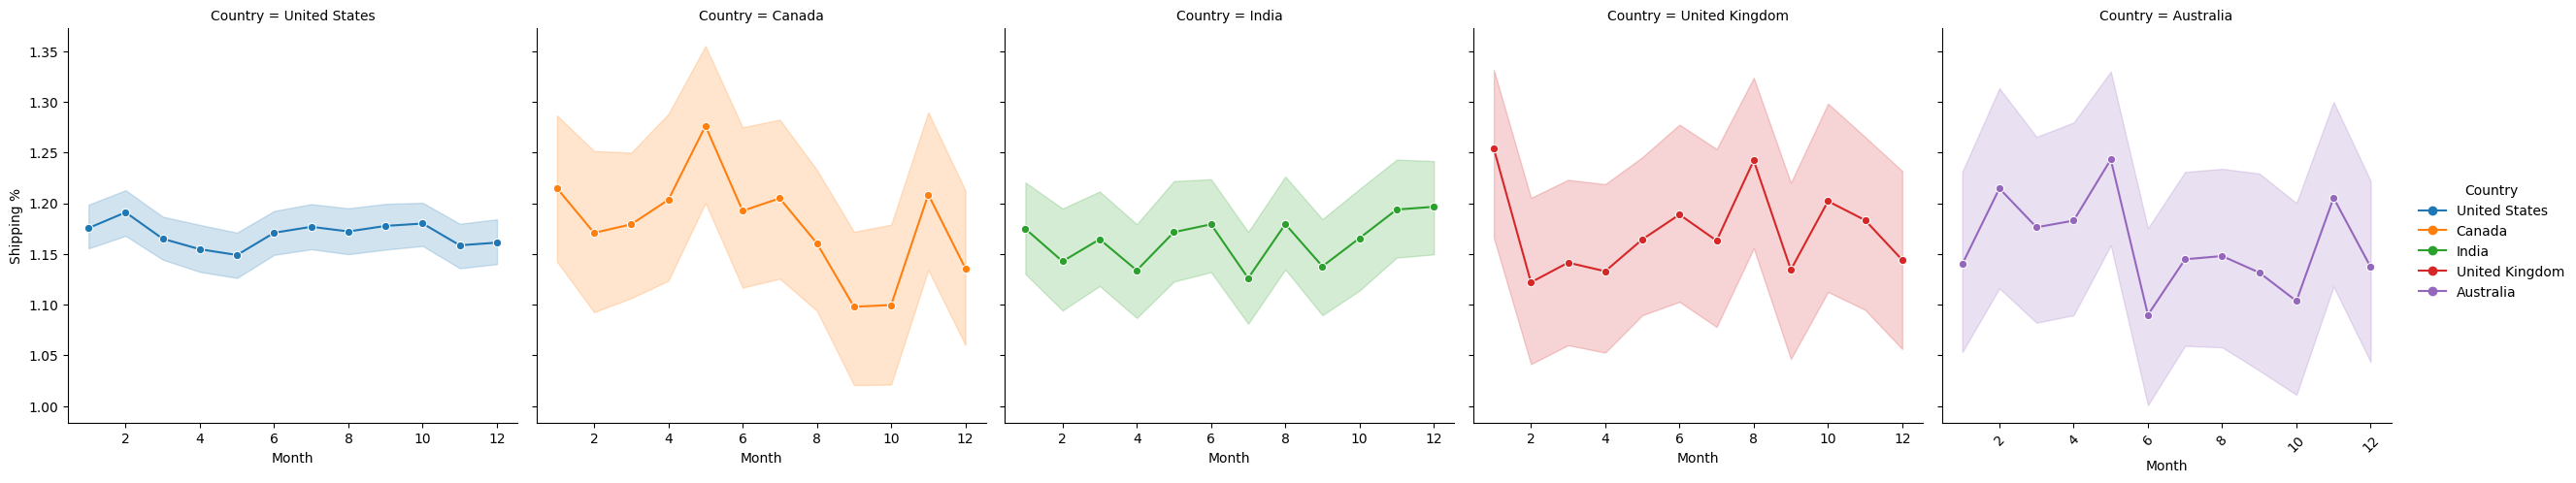

In [ ]:
sns.relplot(data=df, x='Month', y='Shipping %', hue='Country',col='Country',kind='line', marker='o')
plt.xticks(rotation=45)
plt.show()
#

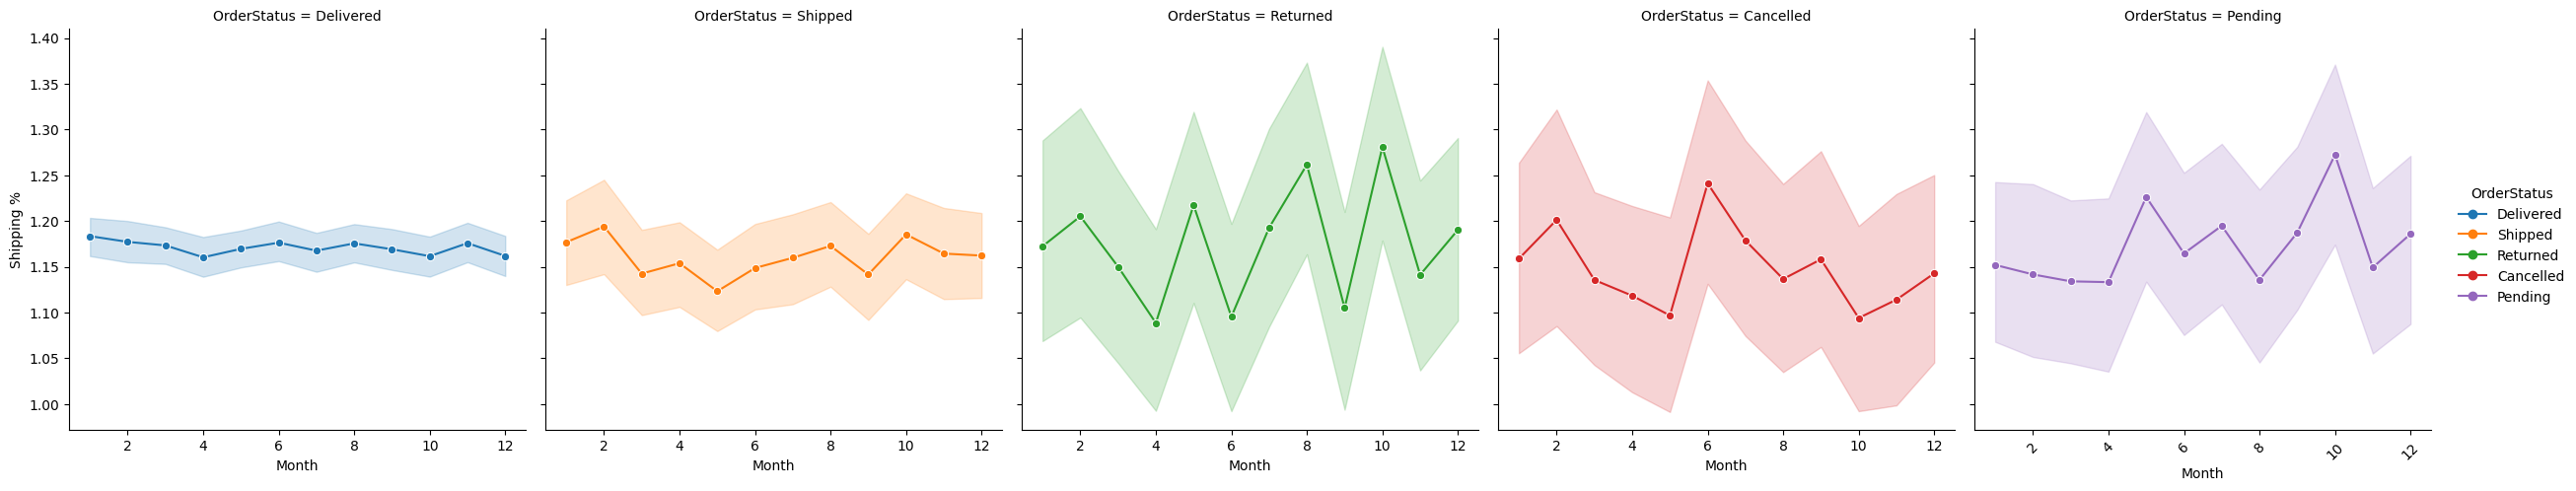

In [ ]:
sns.relplot(data=df, x='Month', y='Shipping %', hue='OrderStatus',col='OrderStatus',kind='line', marker='o')
plt.xticks(rotation=45)
plt.show()
#

# ***Normalization***

In [ ]:
scalr=StandardScaler()
df[['Gross Sales','Discount Amount','Net Sales','Final Amount','Shipping %','Quantity','UnitPrice','Discount','Tax','ShippingCost','TotalAmount']]=scalr.fit_transform(df[['Gross Sales','Discount Amount','Net Sales','Final Amount','Shipping %','Quantity','UnitPrice','Discount','Tax','ShippingCost','TotalAmount']])

In [ ]:
df = pd.get_dummies(df, columns=['ProductName', 'Category', 'Brand', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country'], drop_first=True)

# **ML Model**

In [ ]:
monthly_df = df.groupby(['year', 'Month']).sum(numeric_only=True).reset_index()

In [ ]:
monthly_df['Graph_Date'] = pd.to_datetime(monthly_df['year'].astype(str) + '-' + monthly_df['Month'].astype(str) + '-01')

In [ ]:
monthly_df = monthly_df.sort_values('Graph_Date')

In [ ]:
df_final = df.drop(columns=['OrderID','CustomerID','ProductID','SellerID'])

print(df_final.columns.tolist())

['OrderDate', 'CustomerName', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'Gross Sales', 'Discount Amount', 'Net Sales', 'Final Amount', 'Tax Rate %', 'Shipping %', 'year', 'Month', 'ProductName_Action Camera', 'ProductName_Air Fryer', 'ProductName_Backpack', 'ProductName_Bluetooth Speaker', 'ProductName_Board Game', 'ProductName_Car Charger', "ProductName_Children's Book", 'ProductName_Cookware Set', 'ProductName_Desk Organizer', 'ProductName_Desk Plant', 'ProductName_Dress Shirt', 'ProductName_Drone Mini', 'ProductName_Electric Kettle', 'ProductName_External HDD 2TB', 'ProductName_Fitness Band', 'ProductName_Gaming Mouse', 'ProductName_Graphic Tablet', 'ProductName_HDMI Cable 2m', 'ProductName_Instant Pot', 'ProductName_Jeans', 'ProductName_Kids Toy Car', 'ProductName_LED Desk Lamp', 'ProductName_Laptop Sleeve', 'ProductName_Mechanical Keyboard', 'ProductName_Memory Card 128GB', 'ProductName_Microphone', 'ProductName_Noise Cancelling Headphones', 'Produ

In [ ]:

y = monthly_df['Quantity']


X = monthly_df.drop(columns=['Quantity','Graph_Date'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
next_month_features = X.tail(1).copy()

next_month_features['year'] = 2025
next_month_features['Month'] = 1

predicted_sales = model.predict(next_month_features)
print(f"تم التوقع بنجاح! الكمية المتوقعة: {predicted_sales[0]:.0f} قطعة")

تم التوقع بنجاح! الكمية المتوقعة: 1 قطعة


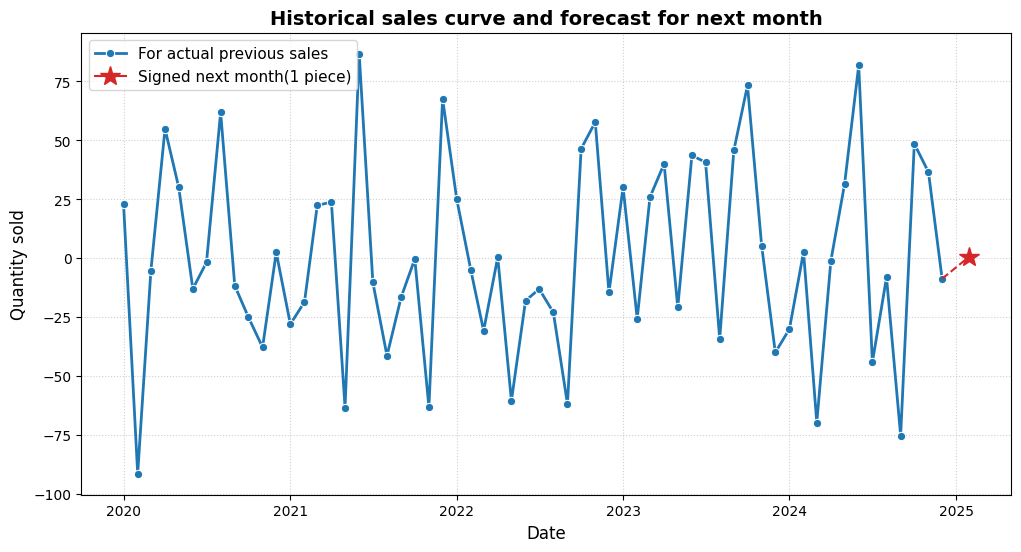

In [ ]:

next_month_date = pd.to_datetime('2025-1-29')
predicted_value = predicted_sales[0]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_df,
    x='Graph_Date',
    y='Quantity',
    marker='o',
    label='For actual previous sales',
    color='tab:blue',
    linewidth=2
)

plt.plot(
    next_month_date,
    predicted_value,
    marker='*',
    markersize=15,
    color='tab:red',
    label=f'Signed next month({predicted_value:.0f} piece)'
)


last_real_date = monthly_df['Graph_Date'].iloc[-1]
last_real_val = monthly_df['Quantity'].iloc[-1]
plt.plot([last_real_date, next_month_date], [last_real_val, predicted_value], color='tab:red', linestyle='--')

plt.title('Historical sales curve and forecast for next month', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Quantity sold', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# عرض الرسمة
plt.show()